In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

DATA = Path("../../data")

LABELS = ["ACL", "MCL", "Medial Meniscus", "Lateral Meniscus", "Medial OA", "Lateral OA",
          "PF OA", "Effusion", "Synovitis", "Baker's", "Contusion", "Fracture"]

# X / Y / Z are the three radiological planes: a stack steps along the axis its
# images are perpendicular to - sagittal along x, coronal along y, axial along z.
AXIS_PLANE = {"X": "Sagittal", "Y": "Coronal", "Z": "Axial"}

studies = pd.read_csv(DATA / "train.csv")          # one row per study: Report + 12 labels
series = pd.read_csv(DATA / "train_series.csv")    # one row per series: plane + flags

# extract fully reported and labeled (one of the 58 available) study that comes from kaggle

In [2]:
# 58 of the 4,407 studies carry all 12 labels; the rest are report-only. Take the
# first by UID, so re-running always describes the same knee.
gold = studies[studies[LABELS].notna().all(axis=1)]
study = gold.sort_values("StudyInstanceUID").iloc[0]
print("fully labeled studies:", len(gold), "\n")

fully labeled studies: 58 



# from that serie : return the 3 sets of images (x / y and z)

In [3]:
# One series per plane. A study holds 1-7 series per plane, so it needs a rule:
# fluid-sensitive (PD/T2 fat-sat) wins, since most of the 12 findings are fluid.
mine = series[series.StudyInstanceUID == study.StudyInstanceUID]

sets = {}
for axis, plane in AXIS_PLANE.items():
    row = (mine[mine.Anatomical_Plane == plane]
           .sort_values(["Fluid_Sensitive", "SeriesInstanceUID"], ascending=[False, True])
           .iloc[0])
    sets[axis] = np.load(DATA / "volumes" / f"{row.SeriesInstanceUID}.npz")["data"]
    print("{}  {:<9} {} images of {}x{}  {}".format(
        axis, plane, *sets[axis].shape, sets[axis].dtype))

X  Sagittal  24 images of 224x224  uint8
Y  Coronal   24 images of 224x224  uint8
Z  Axial     24 images of 224x224  uint8


# Print Sagittal

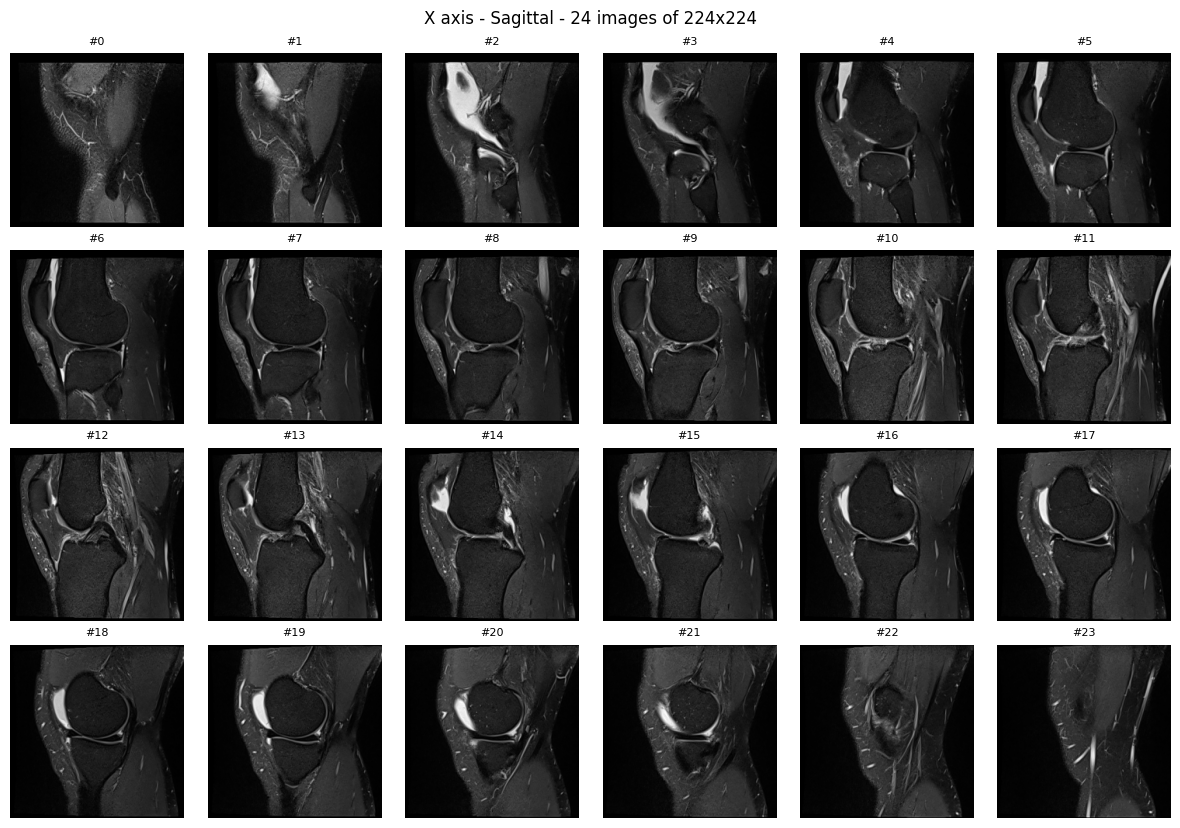

In [4]:
# Print only X: every image in the sagittal set, in stack order.
import matplotlib.pyplot as plt

x = sets["X"]
cols = 6
rows = -(-len(x) // cols)

fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2.1 * rows))
for i, ax in enumerate(axes.ravel()):
    ax.axis("off")
    if i < len(x):
        ax.imshow(x[i], cmap="gray")
        ax.set_title(f"#{i}", fontsize=8)
fig.suptitle("X axis - Sagittal - {} images of {}x{}".format(*x.shape))
plt.tight_layout()
plt.show()

# Turn one Axis into a Tensor

We want one function: a StudyInstanceUID goes in, and out comes

- `x` : the X images as `(24, 224, 224, 1)` decimals between 0 and 1
- `y` : the 12 findings as a vector

1 channel, because the images are monochrome - three identical copies would just cost
3x the memory. A pretrained backbone that wants 3 channels gets the repeat inside the
model, where it is nearly free, not baked into every file we load.

Then a generator on top, so a batch can be pulled without holding 4,407 studies in memory.

In [5]:
# Soft labels, because only 58 studies carry real ones - these cover all 4,407.
# They repeat on every series row of a study, so one row per study is enough.
index = pd.read_csv(DATA / "meta" / "train_index.csv")
SOFT = ["soft_" + label for label in LABELS]
by_study = index.drop_duplicates("StudyInstanceUID").set_index("StudyInstanceUID")

def study_to_tensor(uid, axis="X"):
    """StudyInstanceUID -> ((24, 224, 224, 1) float32 in [0, 1], 12 labels)."""
    rows = series[series.StudyInstanceUID == uid]
    row = (rows[rows.Anatomical_Plane == AXIS_PLANE[axis]]
           .sort_values(["Fluid_Sensitive", "SeriesInstanceUID"], ascending=[False, True])
           .iloc[0])
    vol = np.load(DATA / "volumes" / f"{row.SeriesInstanceUID}.npz")["data"]   # (24,224,224) uint8
    x = vol[..., None].astype(np.float32) / 255.0                              # -> (24,224,224,1)
    y = by_study.loc[uid, SOFT].to_numpy(dtype=np.float32)
    return x, y

x, y = study_to_tensor(study.StudyInstanceUID)
print("x", x.shape, x.dtype, "range [{:.2f}, {:.2f}]  {:.1f} MB".format(x.min(), x.max(), x.nbytes / 1e6))
print("y", y.shape, dict(zip(LABELS, y.round(2))))

x (24, 224, 224, 1) float32 range [0.00, 0.98]  4.8 MB
y (12,) {'ACL': np.float32(0.02), 'MCL': np.float32(0.02), 'Medial Meniscus': np.float32(0.02), 'Lateral Meniscus': np.float32(0.46), 'Medial OA': np.float32(0.02), 'Lateral OA': np.float32(0.02), 'PF OA': np.float32(0.98), 'Effusion': np.float32(0.91), 'Synovitis': np.float32(0.33), "Baker's": np.float32(0.02), 'Contusion': np.float32(0.02), 'Fracture': np.float32(0.02)}


In [6]:
# One study in memory at a time - 4.8 MB each, so all 4,407 would not fit.
# For an ImageNet-pretrained backbone, repeat to 3 channels in the model:
#     keras.layers.Concatenate()([inp, inp, inp])
import tensorflow as tf

def make_dataset(uids, batch_size=4, axis="X"):
    signature = (tf.TensorSpec((24, 224, 224, 1), tf.float32), tf.TensorSpec((12,), tf.float32))
    return (tf.data.Dataset
            .from_generator(lambda: (study_to_tensor(u, axis) for u in uids),
                            output_signature=signature)
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))

train_uids = by_study.index[by_study.fold != 0]          # folds 1-4 train, fold 0 validates
xb, yb = next(iter(make_dataset(train_uids[:8], batch_size=4)))
print("train studies:", len(train_uids))
print("batch x", xb.shape, "  batch y", yb.shape)

train studies: 3525
batch x (4, 24, 224, 224, 1)   batch y (4, 12)


In [7]:
x.shape

(24, 224, 224, 1)

In [8]:
# as (24,224,224,1) is Tensor

# Different scans have different numbers of images

A model needs the **same shape every time**. But the scans do not agree with each other:
one series has 11 images, another has 320.

So we pick one number, `K`, and turn every stack into exactly `K` images.

**Which axis do we change?** A stack is `(number_of_images, 224, 224)`:

| axis | what it is | do we touch it? |
|---|---|---|
| 0 | how many images are in the stack | **yes - this is the one that varies** |
| 1 | image height, always 224 | no |
| 2 | image width, always 224 | no |

In [9]:
# The trick: tf.image.resize expects (height, width, channels).
# If we hand it (n, 224, 224), then "height" IS the number of images.
# So resizing the height from n to K changes how many images we have,
# and leaves every image untouched.
import tensorflow as tf

K = 24

def to_depth(vol, k=K, method="nearest"):
    """Take a stack of any size, give back a stack of exactly k images."""
    return tf.image.resize(vol, [k, vol.shape[1]], method=method)

for n in (16, 22, 24, 40, 160, 1):
    out = to_depth(tf.zeros((n, 224, 224), tf.uint8))
    print(f"{n:>3} images -> {tuple(out.shape)}  {out.dtype.name}")

 16 images -> (24, 224, 224)  uint8
 22 images -> (24, 224, 224)  uint8
 24 images -> (24, 224, 224)  uint8
 40 images -> (24, 224, 224)  uint8
160 images -> (24, 224, 224)  uint8
  1 images -> (24, 224, 224)  uint8


In [10]:
# Why "nearest" and not "bilinear"?
#   nearest  = pick real images out of the stack
#   bilinear = blend two images into a new one the scanner never took
# We want real images. The check below counts how many survive unchanged.
sub = sets["X"][:17]                      # pretend this series only had 17 images
real_ones = lambda out: sum(any((out[i] == s).all() for s in sub) for i in range(K))

for method in ("nearest", "bilinear"):
    out = to_depth(tf.constant(sub, tf.float32), method=method).numpy()
    print(f"{method:<9} {real_ones(out):>2} of {K} images are real (the rest are invented)")

nearest   24 of 24 images are real (the rest are invented)
bilinear   2 of 24 images are real (the rest are invented)


In [11]:
# How many images should K be? Nothing in the CSVs tells us, so we count the files.
# All 4,407 studies / 24,371 series. Takes about 5 minutes on an SSD.
import os

SLOTS = {("Sagittal", 1): "SAG_FLUID", ("Sagittal", 0): "SAG_STRUCT",
         ("Coronal", 1): "COR_FLUID", ("Axial", 1): "AX_FLUID"}
RAW = DATA / "train_series"

counts = {se.name: sum(f.name.endswith(".dcm") for f in os.scandir(se.path))
          for st in os.scandir(RAW) if st.is_dir()
          for se in os.scandir(st.path) if se.is_dir()}

sl = series.assign(n_raw=series.SeriesInstanceUID.map(counts))
sl["slot"] = [SLOTS.get((p, f)) for p, f in zip(sl.Anatomical_Plane, sl.Fluid_Sensitive)]
n_raw = sl.loc[sl.slot.notna(), "n_raw"].dropna().to_numpy()   # only what the encoder sees

print(f"{len(sl):,} series, {len(n_raw):,} slot-eligible   "
      f"median {np.median(n_raw):.0f}   range {n_raw.min():.0f}-{n_raw.max():.0f}")
print()
print(f"{'K':>4} {'downsampled':>12} {'upsampled':>10} {'median kept':>12} {'encoder':>8}")
for k in (16, 20, 24, 28, 32, 40):
    print(f"{k:>4} {(n_raw > k).mean():>11.1%} {(n_raw < k).mean():>9.1%} "
          f"{np.median(np.minimum(k / n_raw, 1.0)):>11.0%} {k / 24:>7.2f}x")

24,371 series, 19,207 slot-eligible   median 30   range 11-320

   K  downsampled  upsampled  median kept  encoder
  16       97.6%      0.9%         53%    0.67x
  20       89.3%      7.9%         67%    0.83x
  24       77.6%     17.8%         80%    1.00x
  28       63.3%     31.8%         93%    1.17x
  32       31.6%     61.4%        100%    1.33x
  40        7.1%     90.0%        100%    1.67x


## What the full data says

We counted the images in all **24,371 series**. The middle stack has **30 images**.
The smallest has 11, the biggest has 320.

### Why do some scans have 320 images?

**Not** because they scanned more of the knee. Because they used **thinner slices**.

Think of slicing a loaf of bread:

- thick slices -> you get 30 slices
- thin slices -> you get 300 slices
- **it is the same loaf either way**

The measurements say exactly this:

| | normal scans | big scans (more than 64 images) |
|---|---|---|
| images in the stack | 30 | 144 |
| thickness of one slice | 3.5 mm | 0.7 mm |
| **how much knee is covered** | **105.6 mm** | **105.6 mm** |

Same knee. Same coverage. Only cut finer. Every single one of the big scans is a
3D scan (`MRAcquisitionType = 3D`), and no normal scan is - the split is clean.

### Should we remove the big scans?

**No.** Two reasons.

1. **They are not broken.** They are the same knee, scanned better. When we keep
   every 5th image from a 144-image stack, we get back an ordinary-looking scan:
   32 images covering 106 mm, which is what a normal scan already is.
2. **The test set has them too.** Removing them from training does not remove them
   from scoring. The model would meet them for the first time when it is graded.

### Which K do we pick?

| K | GPU cost | what goes wrong |
|---|---|---|
| **24** | **1.00x** | drops images on 78% of series |
| 32 | 1.33x | *copies* images on 61% of series |

We keep **K = 24**. K=32 costs 33% more time on every study, and for most series it
just duplicates images we already have.

One thing to keep: **save the original image count** next to each series. After
resampling, a thin-slice 3D scan and an ordinary scan look identical - but only one
of them was measured at 0.7 mm.

# From a DICOM folder straight to a tensor

`to_depth` above works on a stack that is already loaded. This does the whole job:
a folder of `.dcm` files goes in, one fixed-size tensor comes out - no matter how many
images the folder holds. It is what the submit kernel needs, and it reads DICOM directly,
so it does not depend on `data/volumes/`.

Everything below is **self-contained**. The pieces are adapted from
`Aux_functions/dicom_utils3.py` but copied in and fixed here, so this notebook never
depends on that shared file changing under it.

In [12]:
# --- helpers, copied from dicom_utils3.py and fixed (see the notes below) ---
import pydicom

RAW = DATA / "train_series"

def sorted_slice_paths(folder):
    """Order .dcm files by true position along the slice normal - never by filename.

    Reads headers only (stop_before_pixels), so ordering a 320-slice series costs
    almost nothing: we decode pixels later, for the K slices we actually keep.
    """
    heads = []
    for path in sorted(Path(folder).glob("*.dcm")):
        ds = pydicom.dcmread(path, stop_before_pixels=True)
        try:
            iop = np.array(ds.ImageOrientationPatient, dtype=float)
            ipp = np.array(ds.ImagePositionPatient, dtype=float)
            pos = float(np.dot(np.cross(iop[:3], iop[3:]), ipp))
        except AttributeError:
            pos = float(getattr(ds, "InstanceNumber", 0))    # fallback if geometry missing
        heads.append((pos, path))
    return [path for _, path in sorted(heads)]

def raw_slice(ds):
    """Pixel values with the DICOM rescale applied, BEFORE any normalisation."""
    a = ds.pixel_array.astype(np.float32)
    a = a * float(getattr(ds, "RescaleSlope", 1.0)) + float(getattr(ds, "RescaleIntercept", 0.0))
    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        a = a.max() - a                     # in MONOCHROME1 a higher value means darker
    return a

def resize_slice(arr, size):
    """Bilinear resize of one 2D array, pure numpy, half-pixel-center convention."""
    in_h, in_w = arr.shape
    if in_h == size and in_w == size:
        return arr.astype(np.float32)
    row = np.clip((np.arange(size) + 0.5) * (in_h / size) - 0.5, 0, in_h - 1)
    col = np.clip((np.arange(size) + 0.5) * (in_w / size) - 0.5, 0, in_w - 1)
    r0, c0 = np.floor(row).astype(int), np.floor(col).astype(int)
    r1, c1 = np.clip(r0 + 1, 0, in_h - 1), np.clip(c0 + 1, 0, in_w - 1)
    rf, cf = (row - r0)[:, None], (col - c0)[None, :]
    top    = arr[r0][:, c0] * (1 - cf) + arr[r0][:, c1] * cf
    bottom = arr[r1][:, c0] * (1 - cf) + arr[r1][:, c1] * cf
    return (top * (1 - rf) + bottom * rf).astype(np.float32)

In [13]:
def series_to_tensor(series_dir, k=K, img_size=224, pct=(1, 99.5)):
    """A folder of .dcm files (ANY number) -> (k, img_size, img_size, 1) float32 in [0, 1]."""
    paths = sorted_slice_paths(series_dir)
    if not paths:
        return None
    idx = np.linspace(0, len(paths) - 1, k).round().astype(int)   # k REAL images, never black
    raw = [raw_slice(pydicom.dcmread(paths[i])) for i in idx]     # decode only the k we keep
    lo, hi = np.percentile(np.concatenate([r.ravel() for r in raw]), pct)  # ONE window per SERIES
    out = np.stack([resize_slice(np.clip(r, lo, hi), img_size) for r in raw])
    out = (out - lo) / (hi - lo) if hi > lo else np.zeros_like(out)
    return out[..., None].astype(np.float32)

# Same shape out, whatever goes in.
row = series[series.StudyInstanceUID == study.StudyInstanceUID].iloc[0]
x = series_to_tensor(RAW / row.StudyInstanceUID / row.SeriesInstanceUID)
print("tensor:", x.shape, x.dtype, f"[{x.min():.2f}, {x.max():.2f}]")

tensor: (24, 224, 224, 1) float32 [0.00, 1.00]


### Black images, masks, and a hidden bias

`dicom_utils3.sequence_to_array` does the same job as the function above. On long series it
is fine. On short ones it fills the gap with **black images** - and that is worth
understanding, because it is not wrong for the reason it looks like.

**Padding is normal.** Filling a short sequence and telling the model "these slots are
empty" with a **mask** is standard practice. Nothing wrong with it.

**Padding without a mask is the problem.** The black images get added, but no mask comes
with them. The model cannot tell an empty image from real dark anatomy.

**What it does to the numbers.** Averaging over slices simply multiplies the result by
`n / 24`:

| images in the series | true mean | with black padding | with repeated images |
|---|---|---|---|
| 11 | 0.416 | **0.191** | 0.416 |
| 15 | 0.183 | **0.114** | 0.182 |
| 20 | 0.274 | **0.228** | 0.274 |
| 24 | 0.213 | 0.213 | 0.213 |
| 40 | 0.209 | 0.208 | 0.204 |

For 11 images: `0.191 / 0.416 = 0.46`, which is exactly `11/24`. It is not noise, it is a
fixed bias.

**And it flips a correlation.** Measured against the number of images:

| | correlation |
|---|---|
| truth | -0.46 |
| repeated images | -0.47 |
| black padding | **+0.25** |

The feature starts encoding *how many slices the scan had*. We measured above that this
number tells you 2D vs 3D - so the machine, so the hospital. The model learns a shortcut
that has nothing to do with the knee. **That is the real danger, not the black itself.**

**Why this hits M5.** `pool_study` averages over slices, and its mask covers slots only:

```python
avg = keras.ops.mean(t, axis=2)                    # over SLICES  <- takes the bias
m   = keras.Input((SLOTS,), name="present_mask")   # over SLOTS only
```

The `max` branch is sturdier - a black image does not win a max - but not immune: after a
frozen encoder, a black image still produces *some* vector.

**Two fixes, both valid:**

| | good | costs |
|---|---|---|
| **repeat real images** (used above) | no mask needed, the mean stays correct | one image encoded twice; an attention head splits its weight between duplicates |
| **pad + a slice mask** | cleanest: masked mean = true mean | a `(SLOTS, K)` mask has to reach `pool_study` |

Repeating was chosen because it fixes the mean without touching the architecture. What is
**not** defensible is the current mix: pad with black *and* average over it with no mask.

How often does this matter? **3,419 series (17.8%) hold fewer than 24 images**, worst case
13 black out of 24.

### Why normalise, and where

**Normalising is not optional.** MRI numbers have no fixed meaning - there is nothing like
the Hounsfield units of a CT. The same tissue gets a different value on a different
machine. Across 45 random series:

| raw p99.5 | min **212** | median **901** | max **8,098** |
|---|---|---|---|

A **38x spread**. Left as-is, the model learns the scanner, not the knee.

**Do it per SERIES, not per image.** Inside one series, slices differ in brightness by a
median factor of **1.79x**. That difference is real - fluid is brighter on some slices than
others. Normalising each image on its own flattens it to 1.0, and Effusion, Contusion and
Synovitis are all read from *how bright* the fluid is. That is the flaw in
`get_pixel_array`.

**Other options, and why not:**

| approach | why not |
|---|---|
| DICOM `WindowCenter` | present on 100% of series, genuinely worth an A/B test - but it is a display setting, vendor-dependent and sometimes left at a default |
| z-score (mean / std) | moves with how much empty air is in the frame |
| histogram matching (Nyul) | better in principle, but needs a fitted template and a training pass |

The reason to stop at percentile: the 58 gold studies give a macro-AUC confidence interval
about **0.14 wide**. Anything finer cannot be measured here - the same argument that
dropped the rank-mean blend in `02_img_preprocess_all_models`. Percentile fixes the 38x,
keeps the 1.79x, and costs one line.

One thing it does not do: a frozen ImageNet/DINOv2 backbone wants its own mean/std. That
belongs **in the model**, not baked into the file.